# 0장. 진짜 데이터를 직접 받아 보자 🛰️

AI 프로젝트의 첫걸음은 언제나 **데이터 구하기**다.
우리는 기상청 **API허브**(apihub.kma.go.kr)에서 서울의 1962년부터 오늘까지의 관측 기록을 직접 내려받는다.

> **준비물**: 기상청 API허브 회원가입 후 발급받은 인증키.
> 인증키는 코드에 직접 쓰지 않고 `.env` 파일에 `KMA_API_KEY=발급받은키` 한 줄로 저장해 둔다.
> (키를 코드나 화면에 노출하지 않는 것이 보안의 기본!)

이 노트북을 끝까지 실행하면 `KMA.csv`(일별 정리본)가 만들어진다.
이미 이 파일이 있다면 0장은 건너뛰고 1장부터 시작해도 된다.

In [1]:
import urllib.request
import time
from pathlib import Path

import pandas as pd
import numpy as np

# .env 파일에서 인증키 읽기 (현재 폴더 → 상위 폴더 순서로 찾는다)
KEY = None
for p in [".env", "../.env"]:
    if Path(p).exists():
        for line in open(p, encoding="utf-8"):
            if line.startswith("KMA_API_KEY"):
                KEY = line.split("=", 1)[1].strip()
if KEY is None:
    raise RuntimeError(".env 파일에 KMA_API_KEY=... 를 넣어 주세요")
print("인증키 확인: OK (길이", len(KEY), ")")

인증키 확인: OK (길이 22 )


## 0-1. 한 달치 받아 보기

기상청 지상관측(ASOS) 시간자료 API는 기간을 지정하면 텍스트 표를 돌려준다.
서울 관측소 번호는 **108**이다. 먼저 한 달만 받아서 생김새를 구경하자.

In [2]:
URL = "https://apihub.kma.go.kr/api/typ01/url/kma_sfctm3.php"

def fetch_month(yyyymm):
    """해당 연월의 시간별 관측 텍스트를 받아온다"""
    y, m = int(yyyymm[:4]), int(yyyymm[4:])
    last_day = pd.Timestamp(y, m, 1).days_in_month
    url = (f"{URL}?tm1={yyyymm}010000&tm2={yyyymm}{last_day:02d}2300"
           f"&stn=108&help=0&authKey={KEY}")
    return urllib.request.urlopen(url, timeout=60).read().decode("euc-kr", errors="replace")

sample = fetch_month("202408")
print(sample[:6000])          # 앞부분 구경 (#으로 시작하는 줄은 설명)

#START7777
#2345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234
# YYMMDDHHMI STN  WD   WS GST  GST  GST     PA     PS PT    PR    TA    TD    HM    PV     RN     RN     RN     RN     SD     SD     SD WC WP WW                      CA  CA   CH CT        CT  CT  CT    VS   SS    SI ST    TS    TE    TE    TE    TE  ST   WH BF IR IX
#        KST  ID  16  m/s  WD   WS   TM    hPa    hPa  -   hPa     C     C     %   hPa     mm    DAY    JUN    INT    HR3    DAY    TOT -- -- ---------------------- TOT MID  MIN -------- TOP MID LOW                  GD     C     5    10    20    30 SEA    m --  -  -
202408010000 108  20  2.7  -9 -9.0   -9  995.7 1005.3  6  -0.1  27.9  24.1  80.0  30.0   -9.0   -9.0   -9.0   -9.0   -9.0   -9.0   -9.0 -9 -9 -                        8   8   12 Sc         0   0   5  

`#`으로 시작하는 줄은 설명이고, 데이터 줄은 `시각 관측소 풍향 풍속 …` 순서의 숫자들이다.
눈에 띄는 것: **`-9`, `-99` 같은 이상한 값들.** 이건 "관측이 없음(결측)"의 표시다. 나중에 처리한다.

## 0-2. 64년치 전부 받기

1962년 1월부터 이번 달까지 = 약 770번 요청해야 한다. 두 가지 요령을 쓴다:

- **캐시**: 받은 달은 `api_cache/` 폴더에 저장해 두고, 다시 실행하면 건너뛴다 (중간에 끊겨도 이어받기 가능)
- **예의**: 요청 사이에 잠깐 쉰다 (서버를 두들기지 않기)

> ⏳ 처음 실행하면 **20~40분** 걸린다. 한 번 받아두면 그다음부터는 몇 초.

In [3]:
CACHE = Path("api_cache"); CACHE.mkdir(exist_ok=True)

months = pd.period_range("1962-01", pd.Timestamp.today(), freq="M").strftime("%Y%m")
print(f"받을 달 수: {len(months)}")

for i, ym in enumerate(months):
    f = CACHE / f"{ym}.txt"
    if f.exists():
        continue                          # 이미 받은 달은 건너뛰기
    txt = fetch_month(ym)
    time.sleep(0.3)
    f.write_text(txt, encoding="utf-8")
    if i % 50 == 0:
        print(f"  {ym} … ({i+1}/{len(months)})")
print("다운로드 완료!")

받을 달 수: 776
다운로드 완료!


## 0-3. 텍스트를 표로 바꾸기

받아 둔 텍스트를 전부 읽어 하나의 큰 표(DataFrame)로 만든다.

In [4]:
# API 응답의 열 이름 (기상청 문서 기준, 46개)
COLS = ("TM STN WD WS GST_WD GST_WS GST_TM PA PS PT PR TA TD HM PV RN RN_DAY RN_JUN RN_INT "
        "SD_HR3 SD_DAY SD_TOT WC WP WW CA_TOT CA_MID CH_MIN CT CT_TOP CT_MID CT_LOW VS SS SI "
        "ST_GD TS TE_005 TE_01 TE_02 TE_03 ST_SEA WH BF IR IX").split()

rows = []
for f in sorted(CACHE.glob("*.txt")):
    for line in f.read_text(encoding="utf-8").splitlines():
        if line.startswith("#") or not line.strip():
            continue
        parts = line.split()
        if len(parts) == len(COLS) and parts[0].isdigit():
            rows.append(parts)

raw = pd.DataFrame(rows, columns=COLS)
print(f"시간별 관측 {len(raw):,}행")
raw.head(10000000000000000000000000000000000)

시간별 관측 566,797행


,TM,STN,WD,WS,GST_WD,GST_WS,GST_TM,PA,PS,PT,...,TS,TE_005,TE_01,TE_02,TE_03,ST_SEA,WH,BF,IR,IX
0,196201010000,108,-9,-9.0,-9,-9.0,-9,-9.0,-9.0,-9,...,-9.0,-99.0,-99.0,-99.0,-99.0,-9,-9.0,-9,-9,-9
1,196201010100,108,-9,1.3,-9,-9.0,-9,-9.0,-9.0,-9,...,-9.0,-99.0,-99.0,-99.0,-99.0,-9,-9.0,-9,-9,-9
2,196201010200,108,-9,1.7,-9,-9.0,-9,-9.0,-9.0,-9,...,-9.0,-99.0,-99.0,-99.0,-99.0,-9,-9.0,-9,-9,-9
3,196201010300,108,-9,0.0,-9,-9.0,-9,1006.6,1017.3,-9,...,-2.2,-1.0,-0.6,0.3,0.5,-9,-9.0,-9,-9,-9
4,196201010400,108,-9,0.0,-9,-9.0,-9,-9.0,-9.0,-9,...,-9.0,-99.0,-99.0,-99.0,-99.0,-9,-9.0,-9,-9,-9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566792,202608301600,108,2,1.9,-9,-9.0,-9,997.4,1007.0,-9,...,29.7,28.0,28.0,27.9,27.3,-9,-9.0,-9,3,2
566793,202608301700,108,2,2.3,-9,-9.0,-9,997.5,1007.1,-9,...,28.7,28.0,28.0,28.0,27.4,-9,-9.0,-9,3,2
566794,202608301800,108,2,2.4,-9,-9.0,-9,997.8,1007.4,5,...,27.4,27.9,27.9,27.9,27.4,-9,-9.0,-9,3,2
566795,202608301900,108,5,1.9,-9,-9.0,-9,997.7,1007.4,-9,...,26.7,27.7,27.8,27.9,27.4,-9,-9.0,-9,3,-9


## 0-4. 결측치 처리 — 지어내지 말고, 정직하게 버리기

여기가 이 장에서 가장 중요한 부분이다. 원본에는 함정이 있다.

1. **`-9`와 `-99`는 기온 -9도가 아니라 "결측" 표시다.** 옛날 데이터 형식은 빈칸 대신 이런 숫자를 넣었다.
2. **그런데 기온(TA) 열의 -9.0은 진짜 영하 9도일 수 있다!** 서울 겨울은 실제로 -9도까지 내려간다.
   실제로 세어 보면 TA=-9.0은 344번 나오는데 이웃 값(-8.9는 285번, -9.1은 353번)과 비슷한 빈도다.
   반면 -99.0은 7만 번 넘게 나온다. → **기온의 결측 표시는 -99뿐**이고, -9.0은 진짜 관측값이다.
   (습도·풍속·기압은 음수가 물리적으로 불가능하니 -9도 -99도 모두 결측이다)
3. **강수량의 결측은 "비가 안 왔다"는 뜻**이라 나중에 0으로 채운다.

원칙 하나: **값을 지어내지 않는다.** 결측은 NaN(빈칸)으로 정직하게 표시만 해 둔다.

In [5]:
use = raw[["TM", "TA", "HM", "WS", "PS", "RN_DAY"]].copy()   # 쓸 열만 남기기
for c in ["TA", "HM", "WS", "PS", "RN_DAY"]:
    use[c] = pd.to_numeric(use[c], errors="coerce")

# 결측 표시 → NaN (기온은 -99만! 나머지는 -9와 -99 둘 다)
use.loc[np.isclose(use["TA"], -99.0), "TA"] = np.nan
for c in ["HM", "WS", "PS", "RN_DAY"]:
    use.loc[np.isclose(use[c], -9.0) | np.isclose(use[c], -99.0), c] = np.nan

print("열별 결측(NaN) 개수:")
print(use.isna().sum())

열별 결측(NaN) 개수:
TM             0
TA         67447
HM        239239
WS            98
PS        300382
RN_DAY    473362
dtype: int64


기온보다 습도·기압의 결측이 훨씬 많다 — 옛날에는 이런 항목을 하루 몇 번만 관측했기 때문이다.

## 0-5. 시간별 → 일별: 변수 7개로 요약하기

지금 표는 "1시간에 한 줄"인데, 우리 문제는 "**내일** 최고기온 맞히기" — 하루 단위다.
그래서 하루치(최대 24줄)를 **한 줄로 요약**한다. 어떻게 요약할지는 우리가 정하는 설계다:

| 만들 변수 | 요약 방법 | 이유 |
|---|---|---|
| `tmax` / `tmin` | 기온의 하루 **최대 / 최소** | 예측 대상이 최고기온이니까 |
| `ta_mean` | 기온의 하루 **평균** | 하루 전체의 열 상태 |
| `hm_mean` / `ws_mean` / `ps_mean` | 습도·풍속·기압의 **평균** | 날씨의 배경 조건 |
| `rn_day` | 강수량의 하루 **최대** (누적값이라) | 비 온 날의 기온 억제 효과 |

그리고 결측 원칙을 여기서 적용한다:
**기온 관측이 하루 20시간 미만인 날은 통째로 버린다.**
(관측이 8번뿐인 날의 "최고기온"은 진짜 최고 순간을 놓쳤을 수 있다 — 그런 값은 안 쓰는 게 정직하다)

In [6]:
use["date"] = pd.to_datetime(use["TM"], format="%Y%m%d%H%M").dt.floor("D")

# 하루 단위로 요약 → 7개 변수
g = use.groupby("date")
daily = pd.DataFrame({
    "tmax":    g["TA"].max(),          # 일 최고기온
    "tmin":    g["TA"].min(),          # 일 최저기온
    "ta_mean": g["TA"].mean(),         # 일 평균기온
    "hm_mean": g["HM"].mean(),         # 일 평균습도
    "ws_mean": g["WS"].mean(),         # 일 평균풍속
    "ps_mean": g["PS"].mean(),         # 일 평균 해면기압
    "rn_day":  g["RN_DAY"].max().fillna(0),   # 일 강수량 (결측 = 비 안 옴 = 0)
})

# 기온 관측이 20시간 미만인 날은 통째로 제외
enough = g["TA"].count() >= 20
print(f"관측이 있던 날: {len(daily):,}일 / 그중 부실해서 버린 날: {(~enough).sum():,}일")
daily = daily[enough]

daily.to_csv("KMA.csv", encoding="utf-8-sig")
print(f"저장 완료: KMA.csv ({len(daily):,}일, {daily.index.min().date()} ~ {daily.index.max().date()})")

관측이 있던 날: 23,618일 / 그중 부실해서 버린 날: 3,301일
저장 완료: KMA.csv (20,317일, 1962-01-03 ~ 2026-08-30)


1950~60년대 초는 시간별 관측 자체가 드물어서 많이 버려진다. 그래도 **2만 일 이상**이 남는다 — 충분하다!

## 0-6. 잘 만들어졌나 확인

숫자가 진짜 서울 날씨처럼 생겼는지 마지막으로 눈으로 확인하자.

count    20317.0
mean        17.0
std         10.7
min        -13.7
25%          7.8
50%         18.8
75%         26.3
max         39.4
Name: tmax, dtype: float64


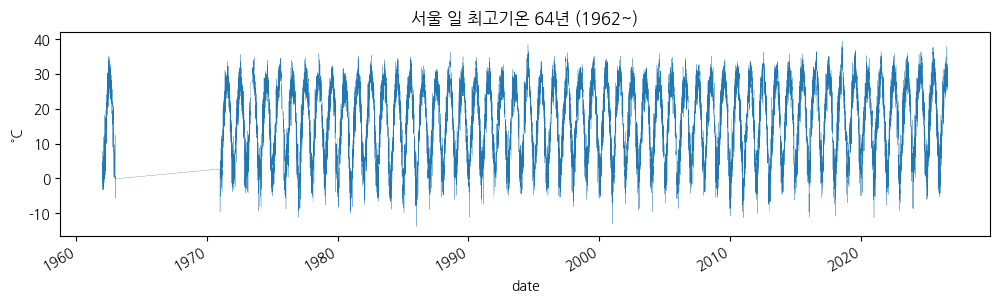

In [42]:
!apt-get -qq install fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

print(daily["tmax"].describe().round(1))   # 최고기온의 분포: 최저 약 -6도, 최고 약 39도면 정상

daily["tmax"].plot(figsize=(12, 3), lw=0.2)
plt.title("서울 일 최고기온 64년 (1962~)")
plt.ylabel("°C")
plt.show()

64년의 계절 물결이 보이면 성공이다. 🎉

이제 `KMA.csv`가 준비됐다. **1장에서 이 데이터로 AI를 만들기 시작한다.**

# 1장 Random Forest 학습

## 1.1 KMS.cvs 불러오기

In [8]:
import pandas as pd
import numpy as np

#0장에서 만든 일별 기상 데이터 불러오기
df = pd.read_csv("KMA.csv",index_col=0, parse_dates=True)

print("데이터 크기:",df.shape)
print("데이터 기간:",df.index.min().date(),"~",df.index.max().date())

display(df.head())

데이터 크기: (20317, 7)
데이터 기간: 1962-01-03 ~ 2026-08-30


,tmax,tmin,ta_mean,hm_mean,ws_mean,ps_mean,rn_day
date,,,,,,,
1962-01-03,2.6,-9.2,-3.508696,60.000000,0.200000,1021.400,0.0
1962-01-04,4.7,-6.5,-1.112500,65.000000,1.350000,1019.100,0.0
1962-01-05,-3.3,-10.3,-6.908333,48.000000,1.008333,1030.625,0.0
1962-01-06,-0.7,-7.4,-4.221739,57.333333,0.433333,1032.450,0.0
1962-01-07,3.4,-6.4,-1.927273,62.666667,1.041667,1033.125,0.0


## 1.2 데이터가 제대로 들어왔는지 확인

In [9]:
print("날짜가 오름차순인지:", df.index.is_monotonic_increasing)

print("＼n처음 날짜:")
print(df.index.min())

print("＼n마지막 날짜")
print(df.index.max())

print("＼n각 변수의 결측값 개수:")
print(df.isna().sum())

날짜가 오름차순인지: True
＼n처음 날짜:
1962-01-03 00:00:00
＼n마지막 날짜
2026-08-30 00:00:00
＼n각 변수의 결측값 개수:
tmax       0
tmin       0
ta_mean    0
hm_mean    0
ws_mean    0
ps_mean    0
rn_day     0
dtype: int64


## 1.3 과거날씨를 입력 변수로 만들기

In [10]:
df["tmax_1"] = df["tmax"].shift(1)
df["tmax_2"] = df["tmax"].shift(2)
df["tmax_3"] = df["tmax"].shift(3)
df["tmax_7"] = df["tmax"].shift(7)

df["tmin_1"] = df["tmin"].shift(1)
df["ta_mean_1"] = df["ta_mean"].shift(1)

df["hm_mean_1"] = df["hm_mean"].shift(1)
df["ws_mean_1"] = df["ws_mean"].shift(1)
df["ps_mean_1"] = df["ps_mean"].shift(1)
df["rn_day_1"] = df["rn_day"].shift(1)

display(df.head(10))

,tmax,tmin,ta_mean,hm_mean,ws_mean,ps_mean,rn_day,tmax_1,tmax_2,tmax_3,tmax_7,tmin_1,ta_mean_1,hm_mean_1,ws_mean_1,ps_mean_1,rn_day_1
date,,,,,,,,,,,,,,,,,
1962-01-03,2.6,-9.2,-3.508696,60.000000,0.200000,1021.400,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-04,4.7,-6.5,-1.112500,65.000000,1.350000,1019.100,0.0,2.6,NaN,NaN,NaN,-9.2,-3.508696,60.000000,0.200000,1021.400,0.0
1962-01-05,-3.3,-10.3,-6.908333,48.000000,1.008333,1030.625,0.0,4.7,2.6,NaN,NaN,-6.5,-1.112500,65.000000,1.350000,1019.100,0.0
1962-01-06,-0.7,-7.4,-4.221739,57.333333,0.433333,1032.450,0.0,-3.3,4.7,2.6,NaN,-10.3,-6.908333,48.000000,1.008333,1030.625,0.0
1962-01-07,3.4,-6.4,-1.927273,62.666667,1.041667,1033.125,0.0,-0.7,-3.3,4.7,NaN,-7.4,-4.221739,57.333333,0.433333,1032.450,0.0
1962-01-08,4.0,-5.9,-1.445833,71.333333,1.050000,1027.525,0.0,3.4,-0.7,-3.3,NaN,-6.4,-1.927273,62.666667,1.041667,1033.125,0.0
1962-01-09,7.8,-2.0,2.383333,68.666667,1.895833,1023.125,0.0,4.0,3.4,-0.7,NaN,-5.9,-1.445833,71.333333,1.050000,1027.525,0.0
1962-01-10,5.1,-0.6,1.883333,74.000000,1.662500,1023.400,0.0,7.8,4.0,3.4,2.6,-2.0,2.383333,68.666667,1.895833,1023.125,0.0
1962-01-11,3.3,0.0,1.412500,88.666667,1.091667,1021.850,0.0,5.1,7.8,4.0,4.7,-0.6,1.883333,74.000000,1.662500,1023.400,0.0


## 1.4  다음날 최고기온을 정답으로 만들기

In [11]:
df["target"] = df["tmax"].shift(-1)

display(df[["tmax", "target"]].head(10))

,tmax,target
date,,
1962-01-03,2.6,4.7
1962-01-04,4.7,-3.3
1962-01-05,-3.3,-0.7
1962-01-06,-0.7,3.4
1962-01-07,3.4,4.0
1962-01-08,4.0,7.8
1962-01-09,7.8,5.1
1962-01-10,5.1,3.3
1962-01-11,3.3,4.1


## 1.5 X와y만들기

In [12]:
features = ["tmax_1","tmax_2","tmax_3","tmax_7","tmin_1","ta_mean_1","hm_mean_1","ws_mean_1","ps_mean_1","rn_day_1"]

X = df[features]
y = df["target"]

print("입력 변수 개수:", len(features))
print("X 크기:", X.shape)
print("y크기:", y.shape)

입력 변수 개수: 10
X 크기: (20317, 10)
y크기: (20317,)


## 1.6 빈 데이터 제거

In [13]:
data = pd.concat([X,y], axis=1).dropna()

X = data[features]
y = data["target"]

print("최종 데이터:",len(data), "일")
print("결측값 개수:",data.isna().sum())

최종 데이터: 20309 일
결측값 개수: tmax_1       0
tmax_2       0
tmax_3       0
tmax_7       0
tmin_1       0
ta_mean_1    0
hm_mean_1    0
ws_mean_1    0
ps_mean_1    0
rn_day_1     0
target       0
dtype: int64


## 1.7 학습/테스트 데이터 분리

In [14]:
train = data[data.index < "2021-01-01"]
test = data[data.index >= "2021-01-01"]

X_train = train[features]
y_train = train["target"]


X_test = test[features]
y_test = test["target"]

print("학습 데이터:", len(train), "일")
print("테스트 데이터:", len(test), "일")

학습 데이터: 18246 일
테스트 데이터: 2063 일


## 1.8 Random Forest 학습

In [15]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)

model.fit(X_train, y_train)

print("Ai 학습 완료!")

Ai 학습 완료!


## 1.9 테스트 데이터 예측

In [16]:
pred = model.predict(X_test)

print("예측 완료!")
print("처음 10개의 예측값:")
print(pred[:10])

예측 완료!
처음 10개의 예측값:
[-1.404       2.87133333  2.69933333  1.95733333  3.16166667  1.16966667
 -2.49766667 -3.84933333 -2.87033333 -0.499     ]


## 1.10 실제값과 예측값 비교

In [17]:
result = pd.DataFrame({"actual":y_test.values,"predicted": pred}, index=y_test.index)

display(result.head(20))

,actual,predicted
date,,
2021-01-01,-1.5,-1.404000
2021-01-02,-2.3,2.871333
2021-01-03,0.2,2.699333
2021-01-04,-2.1,1.957333
2021-01-05,-2.2,3.161667
2021-01-06,-8.3,1.169667
2021-01-07,-11.2,-2.497667
2021-01-08,-7.7,-3.849333
2021-01-09,-2.8,-2.870333


## 1.11 MAE 계산

In [18]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, pred)

print(f"평균 절대 오차(MAE): {mae:.2f} ℃")

평균 절대 오차(MAE): 3.08 ℃


## 1.12 그래프

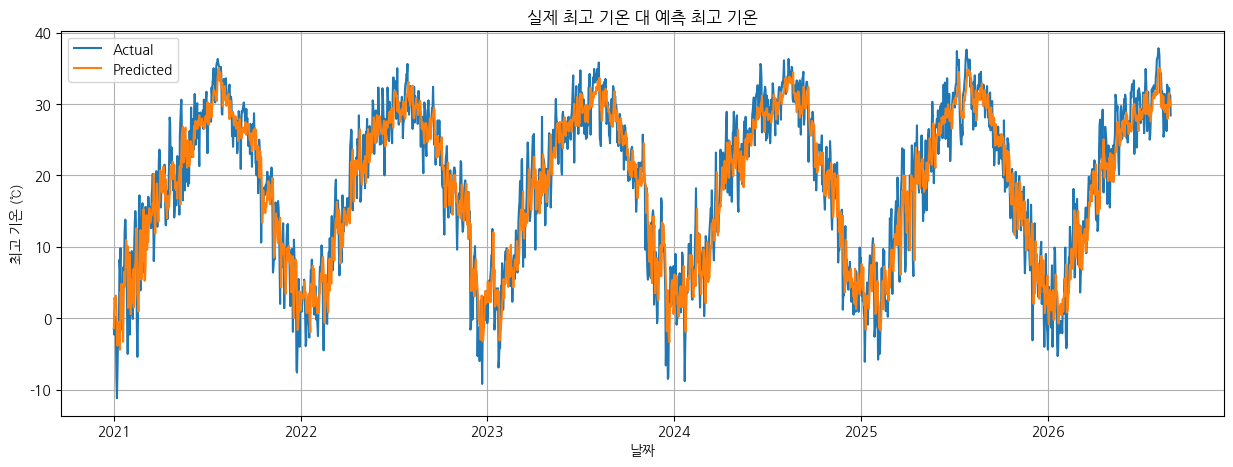

In [36]:


import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(result.index, result["actual"], label="Actual")
plt.plot(result.index, result["predicted"], label="Predicted")

plt.xlabel("날짜")
plt.ylabel("최고 기온 (℃)")
plt.title("실제 최고 기온 대 예측 최고 기온")

plt.legend()
plt.grid()
plt.show()

## 1.13 기준 모델과 비교

In [20]:
baseline_pred = test["tmax_1"]

baseline_mae = mean_absolute_error(y_test, baseline_pred)

print(f"기준 모델 MAE: {baseline_mae:.2f} ℃")
print(f"Random Forest MAE: {mae:.2f} ℃")

기준 모델 MAE: 3.53 ℃
Random Forest MAE: 3.08 ℃


# 2장 Rendom Forest 성능 분석

## 2.1 MAE 다시 확인 하기

In [21]:
from sklearn.metrics import mean_absolute_error
mae_2 = mean_absolute_error(y_test, pred)

print(f"MAE: {mae_2:.2f} ℃")

MAE: 3.08 ℃


## 2.2 RMSE 계산

In [22]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_2 = np.sqrt(mean_squared_error(y_test, pred))

print(f"RMSE: {rmse_2:.2f} ℃")

RMSE: 3.98 ℃


## 2.3 R^2 계산

In [23]:
from sklearn.metrics import r2_score

r2_2 = r2_score(y_test, pred)

print(f"R^2: {r2_2:.3f}")

R^2: 0.863


## 2.4 세 가지 성능 지표 한번에 보기

In [24]:
print("===== Random Forest 성능 분석 =====")
print(f"MAE  : {mae_2:.2f} ℃")
print(f"RMSE : {rmse_2:.2f} ℃")
print(f"R^2  : {r2_2:.3f}")

===== Random Forest 성능 분석 =====
MAE  : 3.08 ℃
RMSE : 3.98 ℃
R^2  : 0.863


## 2.5 실제값과 예측값의 차이 계산

In [25]:
error = y_test - pred

print("예측 오차의 앞부분:")
print(error.head(10))

예측 오차의 앞부분:
date
2021-01-01   -0.096000
2021-01-02   -5.171333
2021-01-03   -2.499333
2021-01-04   -4.057333
2021-01-05   -5.361667
2021-01-06   -9.469667
2021-01-07   -8.702333
2021-01-08   -3.850667
2021-01-09    0.070333
2021-01-10   -3.601000
Name: target, dtype: float64


## 2.6 오차의 평균 확인

In [26]:
print(f"평균 오차: {error.mean():.2f} ℃")
print(f"가장 큰 오차: {error.abs().max():.2f} ℃")

평균 오차: 0.29 ℃
가장 큰 오차: 15.90 ℃


## 2.7 실제값 vs 예측값 그래프

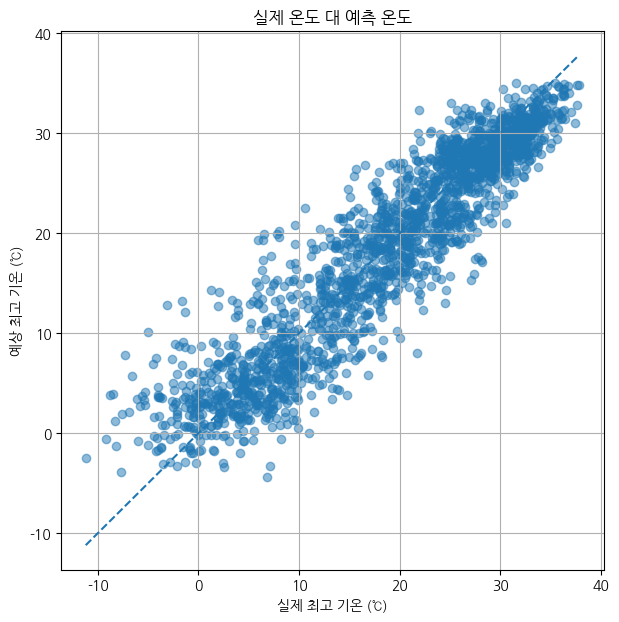

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.scatter(y_test,pred, alpha=0.5)

min_value = min(y_test.min(), pred.min())
max_value = max(y_test.max(), pred.max())

plt.plot([min_value,max_value],[min_value, max_value], linestyle="--")

plt.xlabel("실제 최고 기온 (℃)")
plt.ylabel("예상 최고 기온 (℃)")
plt.title("실제 온도 대 예측 온도")

plt.grid()
plt.show()

## 2.8 예측 오차 분포 그래프

Selecting previously unselected package fonts-nanum.
(Reading database ... 118419 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


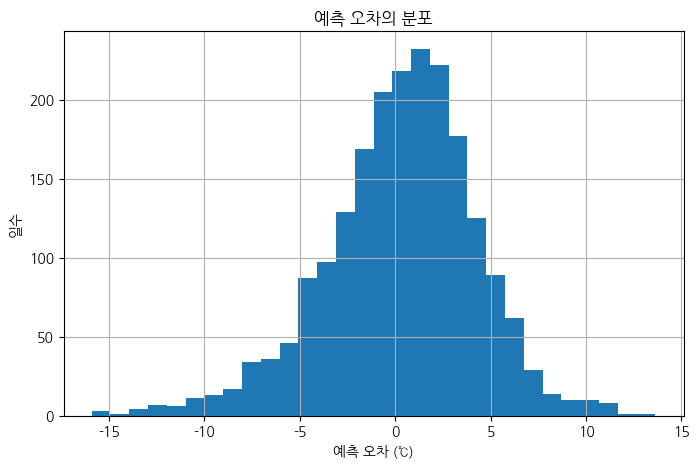

In [33]:
!apt-get -qq install fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(8,5))

plt.hist(error,bins=30)

plt.xlabel("예측 오차 (℃)")
plt.ylabel("일수")
plt.title("예측 오차의 분포")

plt.grid()
plt.show()

## 2.9 가장 크게 틀린 날 찾기

In [29]:
error_abs = error.abs()

worst_days = error_abs.sort_values(ascending=False).head(10)

print("예측 오차가 가장 큰 10일:")
print(worst_days)

예측 오차가 가장 큰 10일:
date
2025-12-02    15.900000
2021-12-24    15.143667
2021-01-28    15.071333
2022-11-29    14.834000
2025-04-15    13.634000
2025-03-28    13.459000
2025-04-13    13.399333
2022-11-30    13.379000
2024-11-26    13.166000
2021-11-08    12.939667
Name: target, dtype: float64


## 2.10 성능 분석 결과 정리

In [30]:
print("================================")
print("    Rendom Forest 성능 분석")
print("================================")

print(f"MAE  :{mae_2:.2f} ℃")
print(f"RMSE :{rmse_2:.2f} ℃")
print(f"R^2  :{r2_2:.3f}")
print(f"평균 오차 :{error.mean():.2f} ℃")
print(f"최대 오차 :{error.abs().max():.2f} ℃")

    Rendom Forest 성능 분석
MAE  :3.08 ℃
RMSE :3.98 ℃
R^2  :0.863
평균 오차 :0.29 ℃
최대 오차 :15.90 ℃


In [34]:
!apt-get -qq install fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False